In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from src.data import *
from src.post_process_functions import *
from src.data_format import format_output, LIST_COLS

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# load metadata
metadata = pd.read_csv(DATA_LABELLED / "metadata_all_reports_220626.csv")

In [3]:
# inspect metadata for labelled reports
appeal_codes = [
    "MDRDZ011",
    "MDRPK026",
    "MDRCM039",
    "MDRBJ019",
    "MDRSD034",
    "MDRNG041",
    "MDRRW022",
    "MDRZM022",
    "MDRUG050",
    "MDRMZ024",
    "MDRIR009",
    "MDRTP004",
    "MDRVU012",
    "MDRDZ007",
    "MDRAF014",
    "MDRCM036",
    "MDRDZ008",
    "MDRPH036",
    "MDRHT018",
    "MDRID013",
    "MDR55001",
    "MDRJO003",
    "MDRLB013",
    "MDRPK018",
    "MDRTJ035",
    "MDRCN006",
    "MDRBD022",
    "MDRYE011",
    "MDRS2001",
    "MDRIQ014",
    "MDRGN015",
    "MDRSV012",
    "MDRMY003",
    "MDRBD015",
    "MDRKE058",
    "MDRCO023",
    "MDRGW003",
    "MDRHU005",
    "MDRPH021",
    "MDRRS015",
    "MDRMN017",
    "MDRGT009",
    "MDRPG008",
    "MDREC019",
    "MDRTN010",
    "MDRCR012",
    "MDRGE019",
    "MDRKZ010",
    "MDRUY004",
]

In [4]:
# or only look at the appeals that were actually labelled
labelled_df = pd.read_csv(
    DATA_LABELLED / f"labelled_reports_all_v24062026.csv"
)
labelled_appeals = labelled_df.appealCode.unique().tolist()

In [5]:
metadata

,reportName,reportLink,disasterType,origType,dateTime,date,location,appealCode,appealType,uid
0,MDRBI016do.pdf,https://adore.ifrc.org/Download.aspx?FileId=28...,-,DREF Operation,2019-12-30T00:00:00+01:00,30/12/2019,Burundi,MDRBI016,DREF Operation,2798360b628f938c1b9e279dee0588dc
1,MDRAL008ou1.pdf,https://adore.ifrc.org/Download.aspx?FileId=28...,Earthquake,Operations Update,2019-12-30T00:00:00+01:00,30/12/2019,Albania,MDRAL008,Operations Update,16e2e057285c77894eddd1dab9decac4
2,MDRPH038ea.pdf,https://adore.ifrc.org/Download.aspx?FileId=28...,Typhoon,Emergency Appeal,2019-12-29T00:00:00+01:00,29/12/2019,Philippines,MDRPH038,-,3ac96244b3e3a53c940cfab03c4ecb8e
3,MDRLK010do.pdf,https://adore.ifrc.org/Download.aspx?FileId=28...,-,DREF Operation,2019-12-27T00:00:00+01:00,27/12/2019,Sri Lanka,MDRLK010,DREF Operation,67ea4b07d0a98cccefe1f221176a157d
4,MDRPH038 EPOA.pdf,https://adore.ifrc.org/Download.aspx?FileId=28...,Typhoon,DREF Operation,2019-12-27T00:00:00+01:00,27/12/2019,Philippines,MDRPH038,DREF Operation,8e9687b2aa7c209025a8d6677919a9e6
...,...,...,...,...,...,...,...,...,...,...
18629,MDRSD013fr.pdf,/docs?file=Appeals/12/MDRSD013fr.pdf,Food Insecurity,Final Report,2014-01-08T16:01:00+01:00,08/01/2014,Sudan,MDRSD013,Final Report,338df2d51fb32ca856190f78fea1c510
18630,MDRSD017dfr.pdf,/docs?file=Appeals/13/MDRSD017dfr.pdf,Population Movement,DREF Operation Final Report,2014-01-07T11:05:00+01:00,07/01/2014,Sudan,MDRSD017,DREF Operation Final Report,19a6f55adaf7f326afb6e3b5b1fbab41
18631,MDRSV006do.pdf,https://adore.ifrc.org/Download.aspx?FileId=53513,-,DREF Operation,2014-01-06T00:00:00+01:00,06/01/2014,El Salvador,MDRSV006,DREF Operation,f5e278f71b22046c595440b330671744
18632,MDRVC002do.pdf,https://adore.ifrc.org/Download.aspx?FileId=53512,-,DREF Operation,2014-01-03T00:00:00+01:00,03/01/2014,St Vincent and Grenadines,MDRVC002,DREF Operation,3e1e610e5af13be644caabe37401b466


In [6]:
labelled_metadata = metadata[metadata["appealCode"].isin(labelled_appeals)]

In [7]:
print(f"Number of appeal codes: {len(labelled_appeals)} ")
print(f"Number of labelled reports: {len(labelled_metadata)} ")

Number of appeal codes: 34 
Number of labelled reports: 186 


In [8]:
missing_appeal_codes = set(labelled_appeals) - set(labelled_metadata["appealCode"])
print(f"Missing appeal codes: {missing_appeal_codes}")

Missing appeal codes: set()


In [9]:
# order dataframe by appeal codes
rank = {v: i for i, v in enumerate(labelled_appeals)}
labelled_reports = labelled_metadata.sort_values(
    by="appealCode", key=lambda s: s.map(rank)
)

In [10]:
labelled_reports

,reportName,reportLink,disasterType,origType,dateTime,date,location,appealCode,appealType,uid
4788,Lebanon - Severe Weather (MDRLB013),https://go-api.ifrc.org/api/DownloadFile/83724...,Cold Wave,MDRLB013fr,2023-10-03T00:00:00+02:00,03/10/2023,Lebanon,MDRLB013,DREF Operation Final Report,0df9cdba1a17753763c64fb4b04aec0e
5141,Lebanon - Severe Weather (MDRLB013),https://go-api.ifrc.org/api/DownloadFile/83723...,Cold Wave,MDRLB013do,2023-02-24T00:00:00+01:00,24/02/2023,Lebanon,MDRLB013,DREF Operation,e94f9ffb43c1fd46e428f295aecee3b8
3779,Vanuatu - Earthquake (MDRVU012),https://go-api.ifrc.org/api/DownloadFile/89728...,Earthquake,MDRVU012_EA,2024-12-20T00:00:00+01:00,20/12/2024,Vanuatu,MDRVU012,Emergency Appeal,34856d66267fb9aca19d0268be976273
3741,Vanuatu - Earthquake (MDRVU012),https://go-api.ifrc.org/api/DownloadFile/89801...,Earthquake,MDRVU012OS,2025-01-12T00:00:00+01:00,12/01/2025,Vanuatu,MDRVU012,Operational strategy,354698614fdb2690394bf49eee57ce3f
3689,Vanuatu - Earthquake (MDRVU012),https://go-api.ifrc.org/api/DownloadFile/89890...,Earthquake,MDRVU012OU1,2025-02-05T00:00:00+01:00,05/02/2025,Vanuatu,MDRVU012,Operations Update,cf05105a27ff4679e1f9452593198dc5
...,...,...,...,...,...,...,...,...,...,...
1577,MDRDZ008do.pdf,https://adore.ifrc.org/Download.aspx?FileId=57...,DREF,DREF Operation,2022-09-05T00:00:00+02:00,05/09/2022,Algeria,MDRDZ008,DREF Operation,272abf1f598ee2578113a0a32e0e4b64
4733,Algeria - Forest Wildfires (MDRDZ008),https://go-api.ifrc.org/api/DownloadFile/R6794...,Fire,MDRDZ008fr,2023-11-10T00:00:00+01:00,10/11/2023,Algeria,MDRDZ008,DREF Operation Final Report,f4140d693d286cfff1c1ee4affbc1a4d
5086,Algeria - Forest Wildfires (MDRDZ008),https://go-api.ifrc.org/api/DownloadFile/84021...,Fire,MDRDZ008DU,2023-03-28T00:00:00+02:00,28/03/2023,Algeria,MDRDZ008,DREF Operation Update,d4a5cef104d7fcc38a92114fd6d19bb4
4214,Cameroon - Landslide (MDRCM036),https://go-api.ifrc.org/api/DownloadFile/85569...,Landslide,MDRCM036dfr,2024-07-04T00:00:00+02:00,04/07/2024,Cameroon,MDRCM036,DREF Operation Final Report,b741be78f799f56ced981e49ef766a02


In [11]:
years_meta = labelled_reports.dateTime.apply(lambda x: pd.to_datetime(x).year).value_counts()
years_labelled = labelled_df.groupby("appealCode").head(1).reportDate.apply(lambda x: pd.to_datetime(x).year).value_counts()

In [12]:
years_meta

dateTime
2024    44
2023    28
2019    28
2025    26
2018    21
2020    17
2021    10
2022     9
2017     3
Name: count, dtype: int64

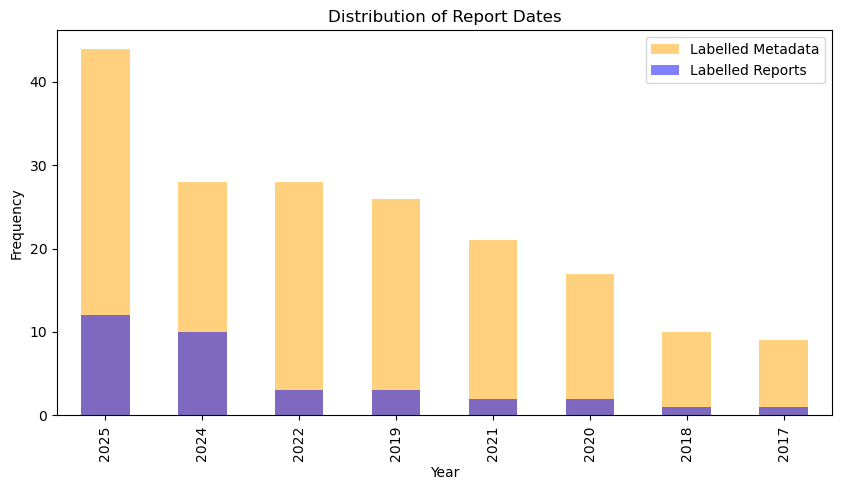

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
#ax.hist(years_meta, bins=20, alpha=0.5, label="Labelled Metadata")
#ax.hist(years_labelled, bins=20, alpha=0.5, label="Labelled Reports")
years_meta.plot(kind="bar", alpha=0.5, label="Labelled Metadata", ax=ax, color="orange")
years_labelled.plot(kind="bar", alpha=0.5, label="Labelled Reports", ax=ax, color="blue")
ax.set_xlabel("Year")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Report Dates")
ax.legend()

In [14]:
labelled_metadata["date"]

17      19/12/2019
19      19/12/2019
28      10/12/2019
42      02/12/2019
50      26/11/2019
           ...    
5085    28/03/2023
5086    28/03/2023
5113    08/03/2023
5141    24/02/2023
5207    30/01/2023
Name: date, Length: 186, dtype: object

In [15]:
labelled_df["reportDate"]

0      2025-12-08
1      2025-12-08
2      2025-12-08
3      2025-12-08
4      2025-12-08
          ...    
800    2025-12-08
801    2025-12-08
802    2025-12-08
803    2025-12-08
804    2025-12-08
Name: reportDate, Length: 805, dtype: object

In [16]:
labelled_metadata["dateTime"] = pd.to_datetime(
    labelled_metadata["date"], format="%d/%m/%Y", errors="coerce"
)
labelled_df["dateTime"] = pd.to_datetime(labelled_df["reportDate"], format="%Y-%m-%d", errors="coerce")
#labelled_df["dateTime"] = pd.to_datetime(labelled_df["reportDate"]).dt.normalize()

#labelled_metadata["dateTime"] = (
#    pd.to_datetime(labelled_metadata["dateTime"], dayfirst=True, utc=True)
#    .dt.tz_convert(None)
#    .dt.normalize()
#)

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_29946/510329605.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labelled_metadata["dateTime"] = pd.to_datetime(


In [19]:
# merge two dataframes to see if there are any differences in the metadata and the labelled reports

merged_metadata = pd.merge(
    labelled_df,
    labelled_metadata,
    left_on=["appealCode", "dateTime"],
    right_on=["appealCode", "dateTime"],
    how="inner",
)

In [22]:
merged_metadata.appealCode.nunique()

18